## Part 1 — PyTorch basics

Tensors:
Tensors are PyTorch's core data structure — N-dimensional arrays with GPU support and autograd.

In [ ]:
import torch

# Create tensors
x = torch.tensor([[1., 2.], [3., 4.]])
y = torch.zeros(2, 3)
z = torch.randn(3, 3)

# Ops: add, matmul, reshape
x + 1       # broadcast
x @ x.T     # matrix multiply
x.view(4)   # flatten

tensor([1., 2., 3., 4.])

In [ ]:
# Shape & dtype
print(f"x.shape: {x.shape}")  # → torch.Size([2, 2])
print(f"x.dtype: {x.dtype}")  # → torch.float32

x.shape: torch.Size([2, 2])
x.dtype: torch.float32


Autograd: PyTorch tracks operations on tensors to compute gradients automatically.

In [ ]:
x = torch.tensor(2., requires_grad=True)
y = x ** 2 + 3 * x   # y = x²+3x

y.backward()  # compute dy/dx
x.grad        # → tensor(7.)  (2x+3 at x=2)

tensor(7.)

PyTorch Training loop skeleton

In [ ]:
# (example loop, not directly runnable)
for epoch in range(num_epochs):
  # 1. Forward pass
  pred = model(X)

  # 2. Compute loss
  loss = criterion(pred, y)

  # 3. Zero gradients
  optimizer.zero_grad()

  # 4. Backprop
  loss.backward()

  # 5. Update weights
  optimizer.step()

## Part 2 — Linear regression with nn.Linear

In [ ]:
# Import Library
import os
import csv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

Using device: cpu



In [ ]:
# REPRODUCIBILITY Seed
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}\n")

Using device: cpu



In [ ]:
# Generate Dataset

# True relationship:  y = 2.5 * x  +  1.0  +  noise
N          = 200
TRUE_W     = 2.5
TRUE_B     = 1.0
NOISE_STD  = 0.8

X_all = np.random.uniform(-3, 3, size=(N, 1)).astype(np.float32)
y_all = (TRUE_W * X_all + TRUE_B + np.random.randn(N, 1) * NOISE_STD).astype(np.float32)

CSV_PATH = "linear_data.csv"
with open(CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["x", "y"])
    for xi, yi in zip(X_all.flatten(), y_all.flatten()):
        writer.writerow([xi, yi])

print(f"Saved {N} samples to '{CSV_PATH}'")
print(f"True relationship:  y = {TRUE_W}·x + {TRUE_B}\n")

Saved 200 samples to 'linear_data.csv'
True relationship:  y = 2.5·x + 1.0



In [ ]:
# Custom Dataset Class
class RegressionDataset(Dataset):
    """
    Reads a two-column CSV (x, y) and exposes it as a PyTorch Dataset.

    Every Dataset must implement:
      __len__: total number of samples
      __getitem__: return (input, label) for a given index
    """

    def __init__(self, csv_path: str):
        xs, ys = [], []
        with open(csv_path, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                xs.append(float(row["x"]))
                ys.append(float(row["y"]))

        # Store as float32 tensors  with shape  (N, 1)
        self.X = torch.tensor(xs, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(ys, dtype=torch.float32).unsqueeze(1)

    # return length of the dataset
    def __len__(self) -> int:
        return len(self.X)

    # function to get sample from dataset by given idx
    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

In [ ]:
# Read Dataset
dataset = RegressionDataset(CSV_PATH)
print(f"Dataset size : {len(dataset)}")
print(f"Sample [0]   : x={dataset[0][0].item():.3f},  y={dataset[0][1].item():.3f}\n")

Dataset size : 200
Sample [0]   : x=-0.753,  y=-1.426



In [ ]:
# Train / Val Split and Define Dataloader

TRAIN_FRAC = 0.8
train_size = int(TRAIN_FRAC * len(dataset))
val_size   = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples : {train_size}")
print(f"Val   samples : {val_size}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader)}\n")

Train samples : 160
Val   samples : 40
Batch size    : 32
Train batches : 5



In [ ]:
# Inspect one batch
X_batch, y_batch = next(iter(train_loader))
print(f"X_batch shape : {X_batch.shape}   # (batch, features)")
print(f"y_batch shape : {y_batch.shape}\n")

X_batch shape : torch.Size([32, 1])   # (batch, features)
y_batch shape : torch.Size([32, 1])



In [ ]:
# Define Model
class LinearRegressionModel(nn.Module):
    """
    A single fully-connected layer:  output = W * input + b
    This is equivalent to ordinary least-squares linear regression.
    """

    def __init__(self, in_features: int = 1, out_features: int = 1):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

In [ ]:
model = LinearRegressionModel().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
print(f"  weight: {model.linear.weight.data}")
print(f"  bias  : {model.linear.bias.data}\n")

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Total parameters: 2
  weight: tensor([[-0.5711]])
  bias  : tensor([-0.4628])



In [ ]:
# Loss & Optimizer
criterion = nn.MSELoss()                                    # Mean Squared Error
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)    # Stochastic Gradient Descent

In [ ]:
# Training Loop
NUM_EPOCHS    = 50
train_losses  = []
val_losses    = []

for epoch in range(1, NUM_EPOCHS + 1):
  # Train
  model.train()          # activates dropout / batch-norm layers
  running_loss = 0.0

  for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      # Forward
      preds = model(X_batch)

      # Loss
      loss = criterion(preds, y_batch)

      # Zero gradients
      optimizer.zero_grad()

      # Backward
      loss.backward()

      # Update
      optimizer.step()

      running_loss += loss.item() * X_batch.size(0)    # accumulate un-averaged loss

  train_loss = running_loss / train_size

  # Validation
  model.eval()           # disables dropout / batch-norm
  running_val = 0.0

  with torch.no_grad():  # no gradients needed at inference time
      for X_batch, y_batch in val_loader:
          X_batch = X_batch.to(device)
          y_batch = y_batch.to(device)
          preds   = model(X_batch)
          loss    = criterion(preds, y_batch)
          running_val += loss.item() * X_batch.size(0)

  val_loss = running_val / val_size

  train_losses.append(train_loss)
  val_losses.append(val_loss)

  if epoch % 10 == 0 or epoch == 1:
      print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}]  "
            f"train_loss: {train_loss:.4f}   val_loss: {val_loss:.4f}")

Epoch [  1/50]  train_loss: 25.7398   val_loss: 14.8146
Epoch [ 10/50]  train_loss: 0.9962   val_loss: 1.2749
Epoch [ 20/50]  train_loss: 0.6444   val_loss: 0.7772
Epoch [ 30/50]  train_loss: 0.6050   val_loss: 0.6651
Epoch [ 40/50]  train_loss: 0.5999   val_loss: 0.6323
Epoch [ 50/50]  train_loss: 0.5989   val_loss: 0.6211


In [ ]:
# Inspect Learned Parameters
learned_w = model.linear.weight.item()
learned_b = model.linear.bias.item()

print(f"\nLearned  W = {learned_w:.4f}   (true: {TRUE_W})")
print(f"Learned  b = {learned_b:.4f}   (true: {TRUE_B})")


Learned  W = 2.4790   (true: 2.5)
Learned  b = 0.9823   (true: 1.0)


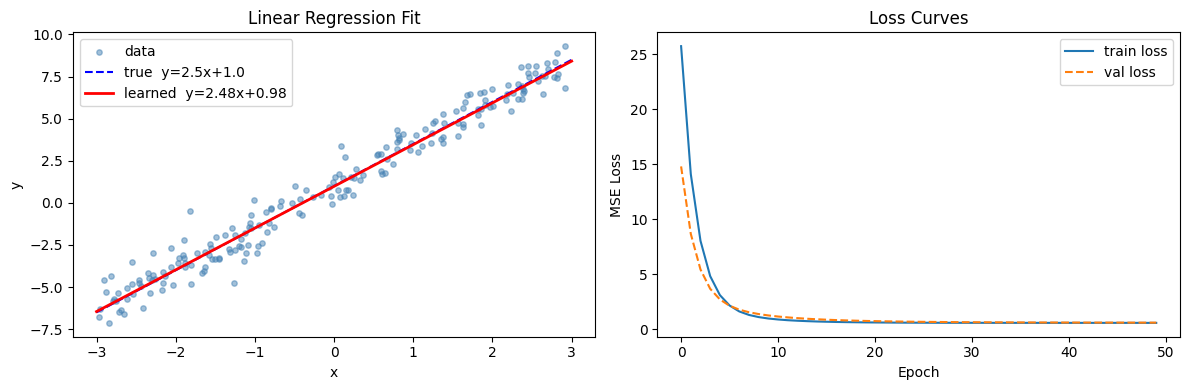


Plot saved to lr_results.png


In [ ]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Data + regression line
ax = axes[0]
ax.scatter(X_all, y_all, s=15, alpha=0.5, label="data", color="steelblue")
x_line = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = TRUE_W * x_line + TRUE_B
with torch.no_grad():
    y_pred = model(torch.tensor(x_line, dtype=torch.float32).to(device)).cpu().numpy()
ax.plot(x_line, y_true, "b--", linewidth=1.5, label=f"true  y={TRUE_W}x+{TRUE_B}")
ax.plot(x_line, y_pred, "r-",  linewidth=2,   label=f"learned  y={learned_w:.2f}x+{learned_b:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Linear Regression Fit")
ax.legend()

# Loss curves
ax = axes[1]
ax.plot(train_losses, label="train loss")
ax.plot(val_losses,   label="val loss",   linestyle="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Loss Curves")
ax.legend()

plt.tight_layout()
plt.savefig("lr_results.png", dpi=120)
plt.show()
print("\nPlot saved to lr_results.png")

## Part 3 — CNN on image data

In [ ]:
# Import Library
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

In [ ]:
# REPRODUCIBILITY Seed
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}\n")

Using device: cuda



In [ ]:
# Dataset — MNIST via torchvision
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.ToTensor(),                        # PIL → float32 tensor [0,1]
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean & std
])
train_dataset = datasets.MNIST(root="./data", train=True,
                                download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False,
                                download=True, transform=transform)
NUM_CLASSES = 10
IMG_SIZE    = 28
CLASS_NAMES = [str(i) for i in range(10)]
print("Loaded MNIST  (60 000 train, 10 000 test)")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.80MB/s]

Loaded MNIST  (60 000 train, 10 000 test)


In [ ]:
# Dataloaders
BATCH_SIZE   = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

imgs, labels = next(iter(train_loader))
print(f"\nBatch X shape : {imgs.shape}     # (batch, channels, H, W)")
print(f"Batch y shape : {labels.shape}")
print(f"Pixel range   : [{imgs.min():.2f}, {imgs.max():.2f}]")

Batch size    : 64
Train batches : 938
Test  batches : 157

Batch X shape : torch.Size([64, 1, 28, 28])     # (batch, channels, H, W)
Batch y shape : torch.Size([64])
Pixel range   : [-0.42, 2.82]


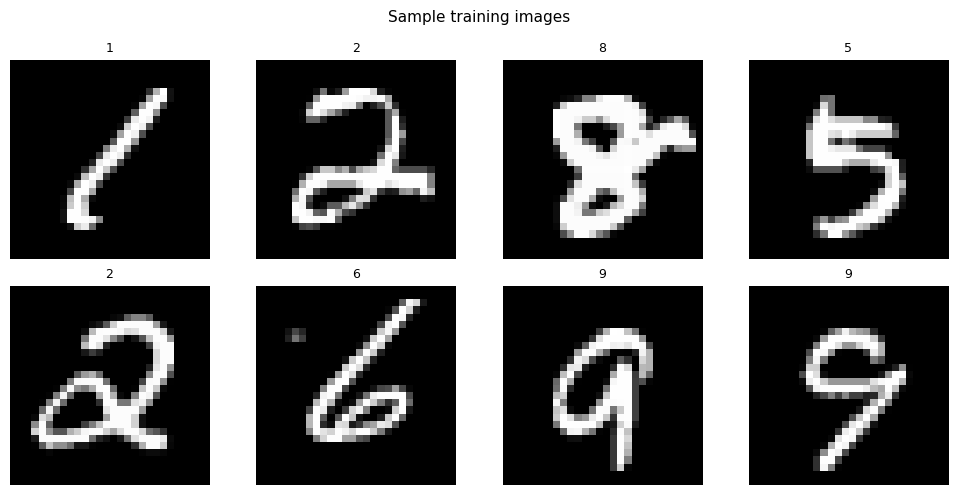

In [ ]:
# Visualize Samples
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, lbl in zip(axes.flatten(), imgs[:8], labels[:8]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"{CLASS_NAMES[lbl.item()]}", fontsize=9)
    ax.axis("off")
fig.suptitle("Sample training images", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Define CNN Model
class CNN(nn.Module):
    """
    A small but complete CNN for image classification.

    Architecture:
      Conv Block 1:  Conv2d(1→16, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
      Conv Block 2:  Conv2d(16→32, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
      Classifier  :  Flatten → Linear(32·6·6 → 128) → ReLU → Dropout → Linear(128 → num_classes)

    For 28×28 input:
      After block 1: 14×14  (MaxPool halves H & W)
      After block 2:  6× 6  (MaxPool after valid conv on 14 → 12 → 6)
    """

    def __init__(self, num_classes: int = 4, in_channels: int = 1):
        super().__init__()

        # CNN Blocks
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Fully-connected classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 6 * 6, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

In [ ]:
model = CNN(num_classes=NUM_CLASSES).to(device)
print(model)

CNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters   : {total_params:,}")
print(f"Trainable params   : {train_params:,}")


Total parameters   : 153,770
Trainable params   : 153,770


In [ ]:
# Loss & Optimizer
criterion = nn.CrossEntropyLoss()                         # Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Adam
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # Learning Rate Scheduler

In [ ]:
# Training
NUM_EPOCHS   = 15
train_losses = []
test_losses  = []
train_accs   = []
test_accs    = []


def evaluate(loader) -> tuple[float, float]:
    """Return (avg_loss, accuracy) on a DataLoader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            loss   = criterion(logits, y_b)
            preds  = logits.argmax(dim=1)
            total_loss += loss.item() * X_b.size(0)
            correct    += (preds == y_b).sum().item()
            total      += X_b.size(0)
    return total_loss / total, correct / total


for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)

        logits = model(X_b)            # forward
        loss   = criterion(logits, y_b)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_b.size(0)
        preds         = logits.argmax(dim=1)
        correct      += (preds == y_b).sum().item()
        total        += X_b.size(0)

    scheduler.step()

    tr_loss = running_loss / total
    tr_acc  = correct / total
    te_loss, te_acc = evaluate(test_loader)

    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    print(f"Epoch [{epoch:2d}/{NUM_EPOCHS}]  "
          f"train loss: {tr_loss:.4f}  acc: {tr_acc*100:.1f}%   "
          f"| test  loss: {te_loss:.4f}  acc: {te_acc*100:.1f}%  "
          f"lr: {scheduler.get_last_lr()[0]:.5f}")

Epoch [ 1/15]  train loss: 0.1813  acc: 94.5%   | test  loss: 0.0669  acc: 98.0%  lr: 0.00100
Epoch [ 2/15]  train loss: 0.0746  acc: 97.7%   | test  loss: 0.0349  acc: 98.7%  lr: 0.00100
Epoch [ 3/15]  train loss: 0.0602  acc: 98.1%   | test  loss: 0.0467  acc: 98.7%  lr: 0.00100
Epoch [ 4/15]  train loss: 0.0511  acc: 98.4%   | test  loss: 0.0334  acc: 98.9%  lr: 0.00100
Epoch [ 5/15]  train loss: 0.0428  acc: 98.7%   | test  loss: 0.0334  acc: 99.0%  lr: 0.00050
Epoch [ 6/15]  train loss: 0.0297  acc: 99.1%   | test  loss: 0.0277  acc: 99.1%  lr: 0.00050
Epoch [ 7/15]  train loss: 0.0259  acc: 99.2%   | test  loss: 0.0275  acc: 99.1%  lr: 0.00050
Epoch [ 8/15]  train loss: 0.0232  acc: 99.2%   | test  loss: 0.0253  acc: 99.2%  lr: 0.00050
Epoch [ 9/15]  train loss: 0.0224  acc: 99.3%   | test  loss: 0.0229  acc: 99.2%  lr: 0.00050
Epoch [10/15]  train loss: 0.0212  acc: 99.4%   | test  loss: 0.0228  acc: 99.3%  lr: 0.00025
Epoch [11/15]  train loss: 0.0150  acc: 99.6%   | test  loss

## Part 4 — Fitting Noisy Labels

In [ ]:
# Import Library
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [ ]:
# REPRODUCIBILITY Seed
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}\n")

Using device: cuda



In [ ]:
# Generate Dataset
class SyntheticShapeDataset(Dataset):
    """
    Generates 28x28 grayscale images of four simple shapes:
      0 = horizontal bar
      1 = vertical bar
      2 = diagonal
      3 = cross (plus sign)

    Gaussian noise is added so pixel patterns are not trivially
    separable. The network must learn spatial structure.
    """

    CLASS_NAMES = ["H-bar", "V-bar", "Diagonal", "Cross"]

    def __init__(self, n_samples: int = 3200, noise_std: float = 0.12):
        self.n   = n_samples
        self.std = noise_std
        self.X, self.y = self._generate()

    def _make_image(self, label: int) -> np.ndarray:
        img = np.zeros((28, 28), dtype=np.float32)
        if label == 0:                           # horizontal bar
            r = np.random.randint(8, 20)
            img[r, 4:24] = 1.0
        elif label == 1:                         # vertical bar
            c = np.random.randint(8, 20)
            img[4:24, c] = 1.0
        elif label == 2:                         # diagonal
            for i in range(4, 24):
                img[i, i] = 1.0
                if i > 4:
                    img[i - 1, i] = 0.5
        else:                                    # cross
            img[14, 4:24] = 1.0
            img[4:24, 14] = 1.0
        return img

    def _generate(self):
        X = np.zeros((self.n, 1, 28, 28), dtype=np.float32)
        y = np.zeros(self.n, dtype=np.int64)
        for i in range(self.n):
            lbl      = i % 4             # balanced classes
            img      = self._make_image(lbl)
            img     += np.random.randn(28, 28) * self.std
            X[i, 0]  = np.clip(img, 0, 1)
            y[i]     = lbl
        return torch.tensor(X), torch.tensor(y)

    def __len__(self):
      return self.n
    def __getitem__(self, idx):
      return self.X[idx], self.y[idx]

In [ ]:
full_dataset = SyntheticShapeDataset(n_samples=3200, noise_std=0.12)
NUM_CLASSES  = 4
CLASS_NAMES  = SyntheticShapeDataset.CLASS_NAMES

In [ ]:
# Fixed train / test split (80/20). Same images in every experiment.
TRAIN_SIZE = 2560
TEST_SIZE  = len(full_dataset) - TRAIN_SIZE

rng_split = torch.Generator().manual_seed(42)
all_indices = torch.randperm(len(full_dataset), generator=rng_split).tolist()
train_indices = all_indices[:TRAIN_SIZE]
test_indices  = all_indices[TRAIN_SIZE:]

print(f"Total samples : {len(full_dataset)}")
print(f"Train / Test  : {TRAIN_SIZE} / {TEST_SIZE}")
print(f"Classes       : {CLASS_NAMES}\n")

Total samples : 3200
Train / Test  : 2560 / 640
Classes       : ['H-bar', 'V-bar', 'Diagonal', 'Cross']



In [ ]:
# Label Corruption Dataset
class NoisyLabelDataset(Dataset):
    """
    Wraps an existing dataset and randomly replaces a fraction
    `noise_rate` of training labels with uniformly random labels.

    Only labels are corrupted; images are unchanged.
    """

    def __init__(self, base_dataset: Dataset, indices: list,
                 noise_rate: float, num_classes: int, seed: int = 0):
        self.base        = base_dataset
        self.indices     = indices
        self.noise_rate  = noise_rate
        self.num_classes = num_classes

        # Collect original labels
        orig_labels = torch.tensor(
            [base_dataset[i][1] for i in indices], dtype=torch.long
        )

        # Corrupt a random subset
        rng = np.random.default_rng(seed)
        n_corrupt = int(len(indices) * noise_rate)
        corrupt_pos = rng.choice(len(indices), size=n_corrupt, replace=False)

        noisy_labels = orig_labels.clone()
        random_labels = torch.tensor(
            rng.integers(0, num_classes, size=n_corrupt),
            dtype=torch.long
        )
        noisy_labels[corrupt_pos] = random_labels

        self.original_labels = orig_labels
        self.labels          = noisy_labels
        self.corrupt_mask    = torch.zeros(len(indices), dtype=torch.bool)
        self.corrupt_mask[corrupt_pos] = True
        self.n_corrupted     = n_corrupt

        self.changed_mask = (self.labels != self.original_labels)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, _ = self.base[self.indices[idx]]   # image unchanged
        return img, self.labels[idx]            # noisy label for training


# Visualization
def visualize_noisy_samples(dataset, class_names=None, n=16, seed=0, figsize=(12, 12)):
    """
    Visualize samples with:
      - image
      - original ground-truth label
      - noisy/corrupted label
      - whether selected for corruption
      - whether label actually changed

    dataset: NoisyLabelDataset
    """
    rng = np.random.default_rng(seed)
    n = min(n, len(dataset))
    sample_ids = rng.choice(len(dataset), size=n, replace=False)

    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, sample_ids):
        img, noisy_label = dataset[idx]
        orig_label = dataset.original_labels[idx].item()
        noisy_label = noisy_label.item()
        selected_for_corruption = dataset.corrupt_mask[idx].item()
        actually_changed = dataset.changed_mask[idx].item()

        # Undo normalization for visualization
        img_show = img.squeeze().cpu() * 0.3081 + 0.1307

        ax.imshow(img_show, cmap="gray")
        ax.axis("off")

        gt_name = class_names[orig_label] if class_names is not None else str(orig_label)
        noisy_name = class_names[noisy_label] if class_names is not None else str(noisy_label)

        status = "changed" if actually_changed else "unchanged"
        picked = "picked" if selected_for_corruption else "clean"

        ax.set_title(
            f"GT: {gt_name}\nNoisy: {noisy_name}\n{picked}, {status}",
            fontsize=10
        )

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

noise=  0.0% | selected=   0/2560 | actually_changed=   0

Visualizing: Clean labels


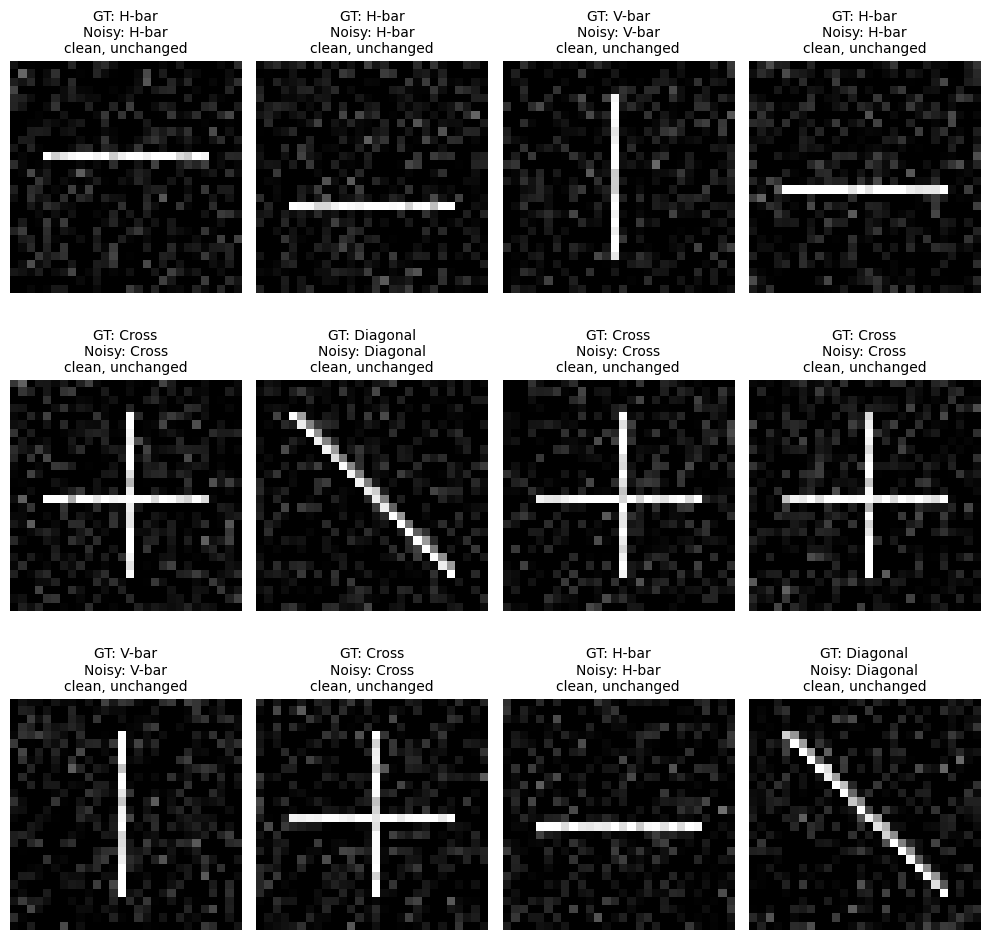

noise= 33.0% | selected= 844/2560 | actually_changed= 621

Visualizing: 33% random labels


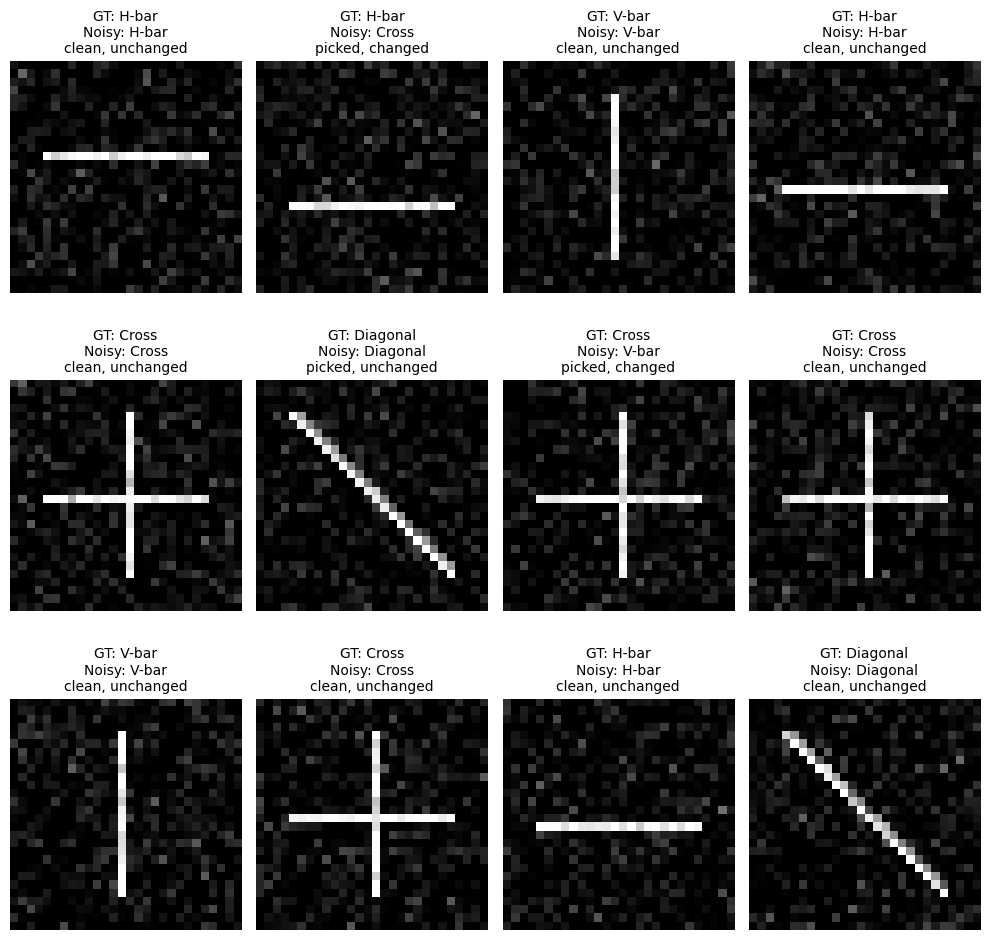

noise= 66.0% | selected=1689/2560 | actually_changed=1262

Visualizing: 66% random labels


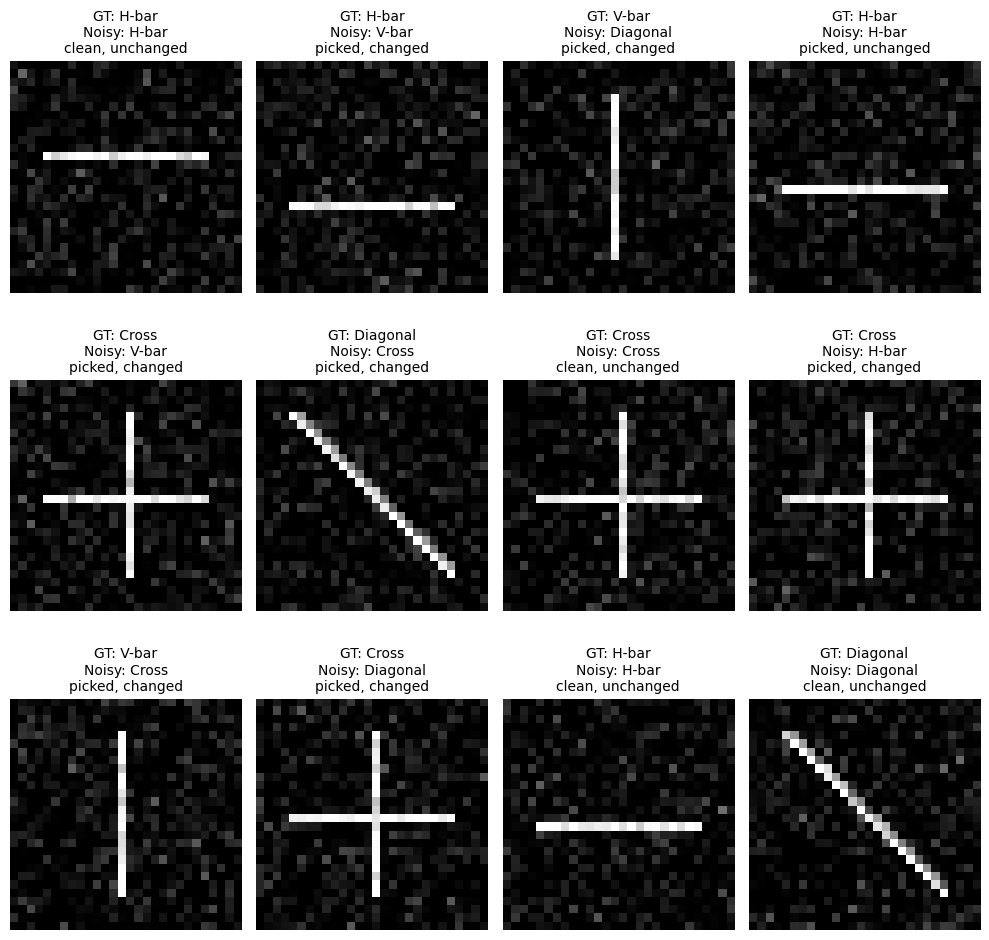

noise=100.0% | selected=2560/2560 | actually_changed=1916

Visualizing: 100% random labels


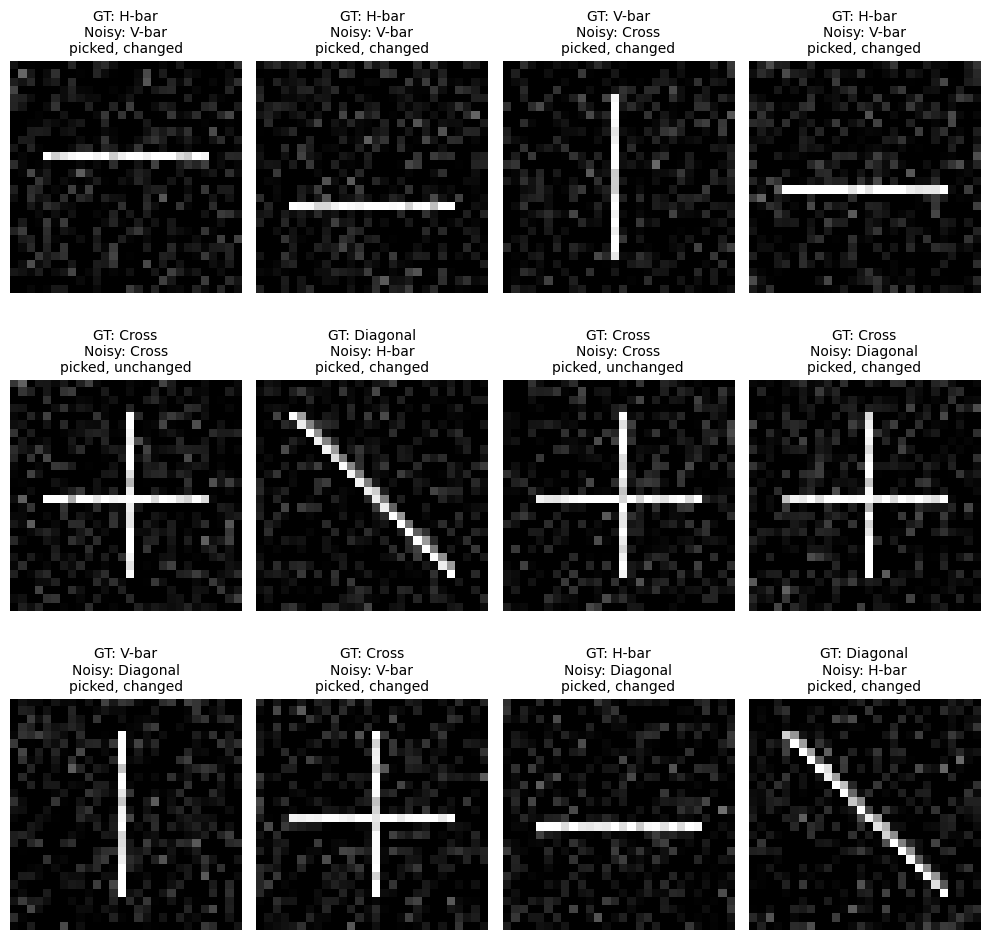

In [ ]:
NOISE_RATES = [0.0, 0.33, 0.66, 1.0]
LABELS_NOISE = {
    0.0:  "Clean labels",
    0.33: "33% random labels",
    0.66: "66% random labels",
    1.0:  "100% random labels",
}

for nr in NOISE_RATES:
    ds = NoisyLabelDataset(full_dataset, train_indices, nr, NUM_CLASSES, seed=42)
    print(
        f"noise={nr*100:5.1f}% | "
        f"selected={ds.n_corrupted:4d}/{len(ds)} | "
        f"actually_changed={(ds.changed_mask.sum().item()):4d}"
    )

    print(f"\nVisualizing: {LABELS_NOISE[nr]}")
    visualize_noisy_samples(ds, class_names=CLASS_NAMES, n=12, seed=42, figsize=(10, 10))

In [ ]:
# Define Model
class CNN(nn.Module):
    """
    The SAME CNN is used in EVERY experiment.
    Any difference in generalisation must come from the labels,
    not from model capacity.

    Architecture:
      Conv Block 1: Conv2d(1->16, 3x3, same) -> BN -> ReLU -> MaxPool  [28->14]
      Conv Block 2: Conv2d(16->32, 3x3, valid) -> BN -> ReLU -> MaxPool [12->6]
      Head:         Flatten -> Linear(1152->256) -> ReLU -> Linear(256->C)
    """

    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 6 * 6, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


model = CNN(NUM_CLASSES)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nParameters: {n_params:,}")
del model

CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=4, bias=True)
  )
)

Parameters: 301,092


In [ ]:
# Define training hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 100

In [ ]:
def run_experiment(noise_rate: float) -> dict:
    """
    Train a fresh CNN with the given label noise level.
    Returns per-epoch train/test loss and accuracy.
    """
    print(f"\n{'─'*60}")
    print(f"  Experiment: {LABELS_NOISE[noise_rate]}  (noise={noise_rate*100:.0f}%)")
    print(f"{'─'*60}")

    # Build datasets
    train_ds = NoisyLabelDataset(full_dataset, train_indices,
                                 noise_rate, NUM_CLASSES, seed=7)
    test_ds  = Subset(full_dataset, test_indices)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0)

    # New model + optimizer for each run
    model     = CNN(NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()

    # SGD with momentum
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01,
                                momentum=0.9, weight_decay=0.0)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.05,
        steps_per_epoch=len(train_loader),
        epochs=NUM_EPOCHS,
        pct_start=0.1,
    )

    history = {"train_loss": [], "train_acc": [],
               "test_loss":  [], "test_acc":  []}

    for epoch in range(1, NUM_EPOCHS + 1):

        # Train
        model.train()
        ep_loss, ep_correct, ep_total = 0.0, 0, 0

        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            loss   = criterion(logits, y_b)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            ep_loss    += loss.item() * X_b.size(0)
            ep_correct += (logits.argmax(1) == y_b).sum().item()
            ep_total   += X_b.size(0)

        tr_loss = ep_loss    / ep_total
        tr_acc  = ep_correct / ep_total

        # Evaluate on CLEAN test set
        model.eval()
        te_loss, te_correct, te_total = 0.0, 0, 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits    = model(X_b)
                loss      = criterion(logits, y_b)
                te_loss    += loss.item() * X_b.size(0)
                te_correct += (logits.argmax(1) == y_b).sum().item()
                te_total   += X_b.size(0)

        te_loss /= te_total
        te_acc   = te_correct / te_total

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch [{epoch:2d}/{NUM_EPOCHS}]  "
                  f"train loss: {tr_loss:.4f}  train acc: {tr_acc*100:.1f}%  |  "
                  f"test acc: {te_acc*100:.1f}%")

    return history

In [ ]:
# Run All Experiments
all_results = {}
for noise_rate in NOISE_RATES:
    all_results[noise_rate] = run_experiment(noise_rate)


────────────────────────────────────────────────────────────
  Experiment: Clean labels  (noise=0%)
────────────────────────────────────────────────────────────
  Epoch [ 1/100]  train loss: 0.3816  train acc: 90.2%  |  test acc: 100.0%
  Epoch [10/100]  train loss: 0.0000  train acc: 100.0%  |  test acc: 100.0%
  Epoch [20/100]  train loss: 0.0000  train acc: 100.0%  |  test acc: 100.0%
  Epoch [30/100]  train loss: 0.0000  train acc: 100.0%  |  test acc: 100.0%
  Epoch [40/100]  train loss: 0.0000  train acc: 100.0%  |  test acc: 100.0%
  Epoch [50/100]  train loss: 0.0000  train acc: 100.0%  |  test acc: 100.0%
  Epoch [60/100]  train loss: 0.0000  train acc: 100.0%  |  test acc: 100.0%
  Epoch [70/100]  train loss: 0.0000  train acc: 100.0%  |  test acc: 100.0%
  Epoch [80/100]  train loss: 0.0000  train acc: 100.0%  |  test acc: 100.0%
  Epoch [90/100]  train loss: 0.0000  train acc: 100.0%  |  test acc: 100.0%
  Epoch [100/100]  train loss: 0.0000  train acc: 100.0%  |  test acc

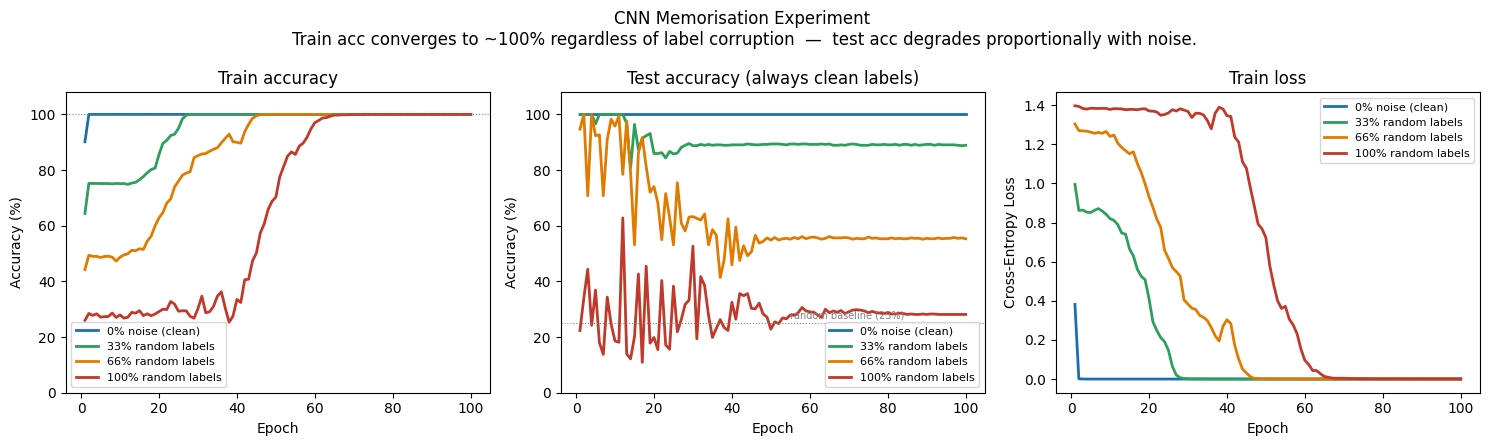

  Saved: lab10_overview.png


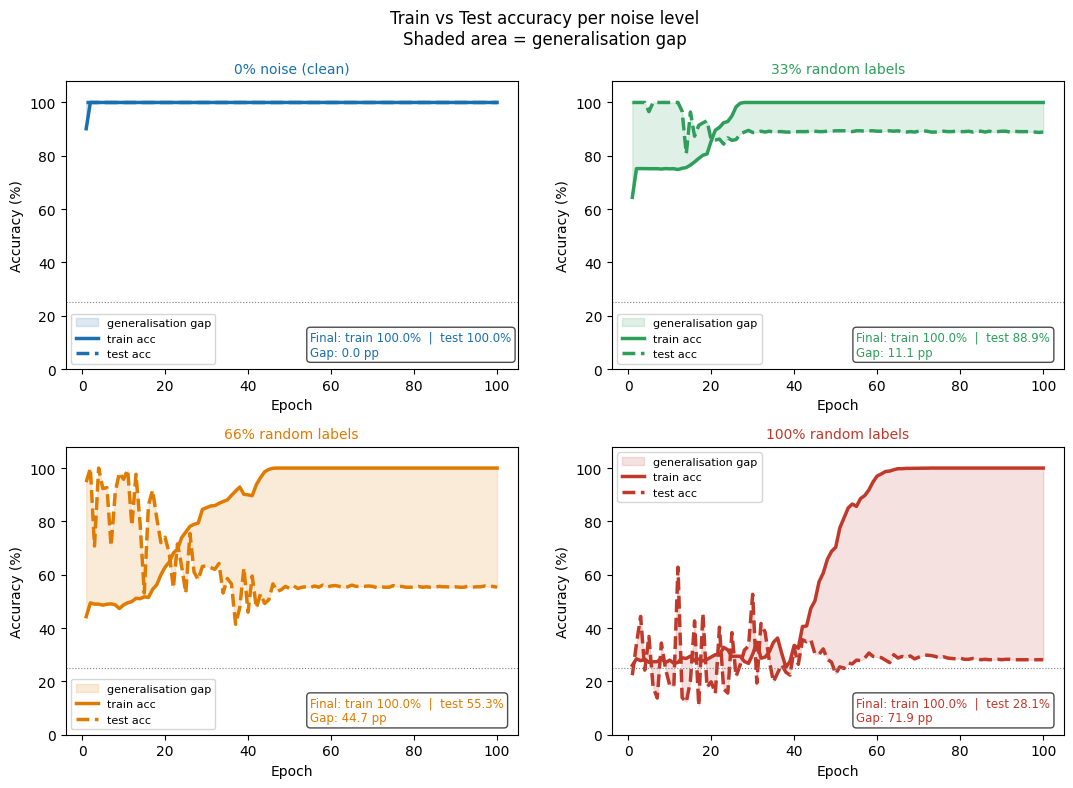

  Saved: lab10_per_condition.png


In [ ]:
# Plotting
COLORS = {
    0.0:  "#1a6faf",
    0.33: "#2e9e5b",
    0.66: "#e07b00",
    1.0:  "#c0392b",
}
LABELS = {
    0.0:  "0% noise (clean)",
    0.33: "33% random labels",
    0.66: "66% random labels",
    1.0:  "100% random labels",
}

epochs   = range(1, NUM_EPOCHS + 1)
baseline = 100.0 / NUM_CLASSES     # random-chance accuracy

# Overview
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Train accuracy
ax = axes[0]
for nr in NOISE_RATES:
    ax.plot(epochs, [a * 100 for a in all_results[nr]["train_acc"]],
            color=COLORS[nr], linewidth=2, label=LABELS[nr])
ax.axhline(100, color="gray", linestyle=":", linewidth=0.8)
ax.set_ylim(0, 108); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Train accuracy")
ax.legend(fontsize=8)

# Figure 1 (Test accuracy)
ax = axes[1]
for nr in NOISE_RATES:
    ax.plot(epochs, [a * 100 for a in all_results[nr]["test_acc"]],
            color=COLORS[nr], linewidth=2, label=LABELS[nr])
ax.axhline(baseline, color="gray", linestyle=":", linewidth=0.8)
ax.text(NUM_EPOCHS * 0.55, baseline + 1.5,
        f"random baseline ({baseline:.0f}%)", fontsize=7, color="gray")
ax.set_ylim(0, 108); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Test accuracy (always clean labels)")
ax.legend(fontsize=8)

# Train loss
ax = axes[2]
for nr in NOISE_RATES:
    ax.plot(epochs, all_results[nr]["train_loss"],
            color=COLORS[nr], linewidth=2, label=LABELS[nr])
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Train loss")
ax.legend(fontsize=8)

fig.suptitle(
    "CNN Memorisation Experiment \n"
    "Train acc converges to ~100% regardless of label corruption  —  "
    "test acc degrades proportionally with noise.",
    fontsize=12
)
plt.tight_layout()
plt.savefig("lab10_overview.png", dpi=130, bbox_inches="tight")
plt.show()
print("  Saved: lab10_overview.png")

# Figure 2 (Generalization Gaps)
fig2, axes2 = plt.subplots(2, 2, figsize=(11, 8))
for ax, nr in zip(axes2.flatten(), NOISE_RATES):
    tr = [a * 100 for a in all_results[nr]["train_acc"]]
    te = [a * 100 for a in all_results[nr]["test_acc"]]
    ax.fill_between(epochs, tr, te, alpha=0.15, color=COLORS[nr],
                    label="generalisation gap")
    ax.plot(epochs, tr, color=COLORS[nr], linewidth=2.5, label="train acc")
    ax.plot(epochs, te, color=COLORS[nr], linewidth=2.5,
            linestyle="--", label="test acc")
    ax.axhline(baseline, color="gray", linestyle=":", linewidth=0.8)
    ax.set_ylim(0, 108)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_title(LABELS[nr], fontsize=10, color=COLORS[nr])
    ax.legend(fontsize=8)
    ax.text(NUM_EPOCHS * 0.55, 5,
            f"Final: train {tr[-1]:.1f}%  |  test {te[-1]:.1f}%\n"
            f"Gap: {tr[-1] - te[-1]:.1f} pp",
            fontsize=8.5, color=COLORS[nr],
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

fig2.suptitle(
    "Train vs Test accuracy per noise level\n"
    "Shaded area = generalisation gap",
    fontsize=12
)
plt.tight_layout()
plt.savefig("lab10_per_condition.png", dpi=300)
plt.show()
print("  Saved: lab10_per_condition.png")

#### This is the famous experiments from the paper "Understanding deep learning requires rethinking generalization" by Chiyuan Zhang et.al. ICLR 2017

#### **Takeways**

1. MEMORISATION CAPACITY

   The CNN reaches ~100% TRAIN accuracy even with fully random
   labels. Deep networks have enough capacity to brute-force
   memorise any finite labelled dataset.

2. GENERALISATION IS NOT FREE

   Test accuracy degrades proportionally with label noise.
   With 100% random labels, test accuracy collapses to the
   random baseline. The model memorised noise, not structure.

3. TRADITIONAL STATISTICAL LEARNING IS NOT ENOUGH

   In classical machine learning, generalization is understood through the lens of model capacity (using tools like VC dimension, Rademacher complexity, or uniform convergence). The classical bias-variance tradeoff dictates that if a model has a high enough capacity to perfectly memorize random noise, it should suffer from massive overfitting and fail to generalize on structured data.

   However, from this experiment, the exact same model can both generalize on real data and memorize completely on noise. Hence, the architecture's inherent "capacity" is not the definite factor of its generalization capabilities.